# Prediction of California Housing Prices using Linear Regression

## Project Overview

Based on the `california_housing.csv` details, let's understand the dataset: 
- longitude: Geographic location 
- latitude: Geographic location
- housing_median_age: Median age of houses
- total_rooms: Number of rooms
- total_bedrooms: Number of bedrooms
- population: Population in the area
- households: Number of households
- median_income: Median income
- median_house_value: Median house price
- ocean_proximity: Distance to ocean

Based on the details, we know that `median_house_value` is our target variable. Other varibales is used to predict it. By evaluating the target variable, we know that the values is continous number, thus this problem is referring to Regression.

<br><br><br><br><br>

## Dataset Understanding

1. **data.head()** - Display the first five rows of the dataset to get a quick overview of its structure, column names, and sample values.

2. **data.shape** - Determine the dimensions of the dataset by showing the number of rows (observations) and columns (features).

3. **data.info()** - Display a summary of the dataset, including data types, non-null values, and memory usage.

4. **data.describe()** - Generate descriptive statistics for all numerical features in the dataset which includes (count, mean, standard deviation, minimum value, 25th percentile, median, 75th perccentile, maximum value). These statistics help us understand the distribution, range, and variation of each numerical feature, and can also provide clues about potential outliers.


In [1]:
import pandas as pd
data = pd.read_csv('california_housing.csv')

print("First 5 rows of dataset:")
print(data.head())

print("\n")

print("Dataset Shape:")
print(data.shape)

print("\n")

print("Dataset Information:")
data.info()

print("\n")

print("Dataset Description:")
print(data.describe())

First 5 rows of dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


Dataset Shape:
(20640, 10)


Dataset Information

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a critical preprocessing step that uses statistical summaries and data visualization to understand data distributions, identify missing values and outliers, uncover feature relationships, and support data-driven decisions for feature engineering and model development.

### Univariative Analysis
Univariative Analysis examines one variable at a time to understand its distribution, central tendency, spread, and possible outliers which helps to identify missing values, unusual distributions, skewness, and data quality issues before modeling.

#### Skewness
Skewness measures the degree of asymmetry in a data distribution. It indicates whether the data is evenly distributed around the center or if it is stretched more toward one side.

##### Types of Skew
1. Symmetric (Normal) 
    - Data is balanced with no significant skew. Mean ≈ Median ≈ Mode. Many statistical methods work well.
    - Balanced data
    - Few extreme values

2. Right-Skewed (Positive Skew)	- Most observations are small, with a few unusually large values. Mean > Median.
    - Many small values
    - Few very large values
    - Possible high-value outliers

3. Left-Skewed (Negative Skew) - Most observations are large, with a few unusually small values. Mean < Median.
    - Many large values
    - Few very small values
    - May result from minimum-value outliers

4. Multiple Peaks (Multimodal) - Data may contain multiple groups, categories, or subpopulations that should be analyzed separately.
    - Different populations exist
    - Possible hidden categories
    - May require clustering or segmentation

5. Strange Cut-off - May indicate data truncation, filtering, collection limits, or artificial constraints (e.g., age cannot be negative).
    - Data has been limited or filtered
    - Measurement boundaries
    - Missing observations beyond a threshold

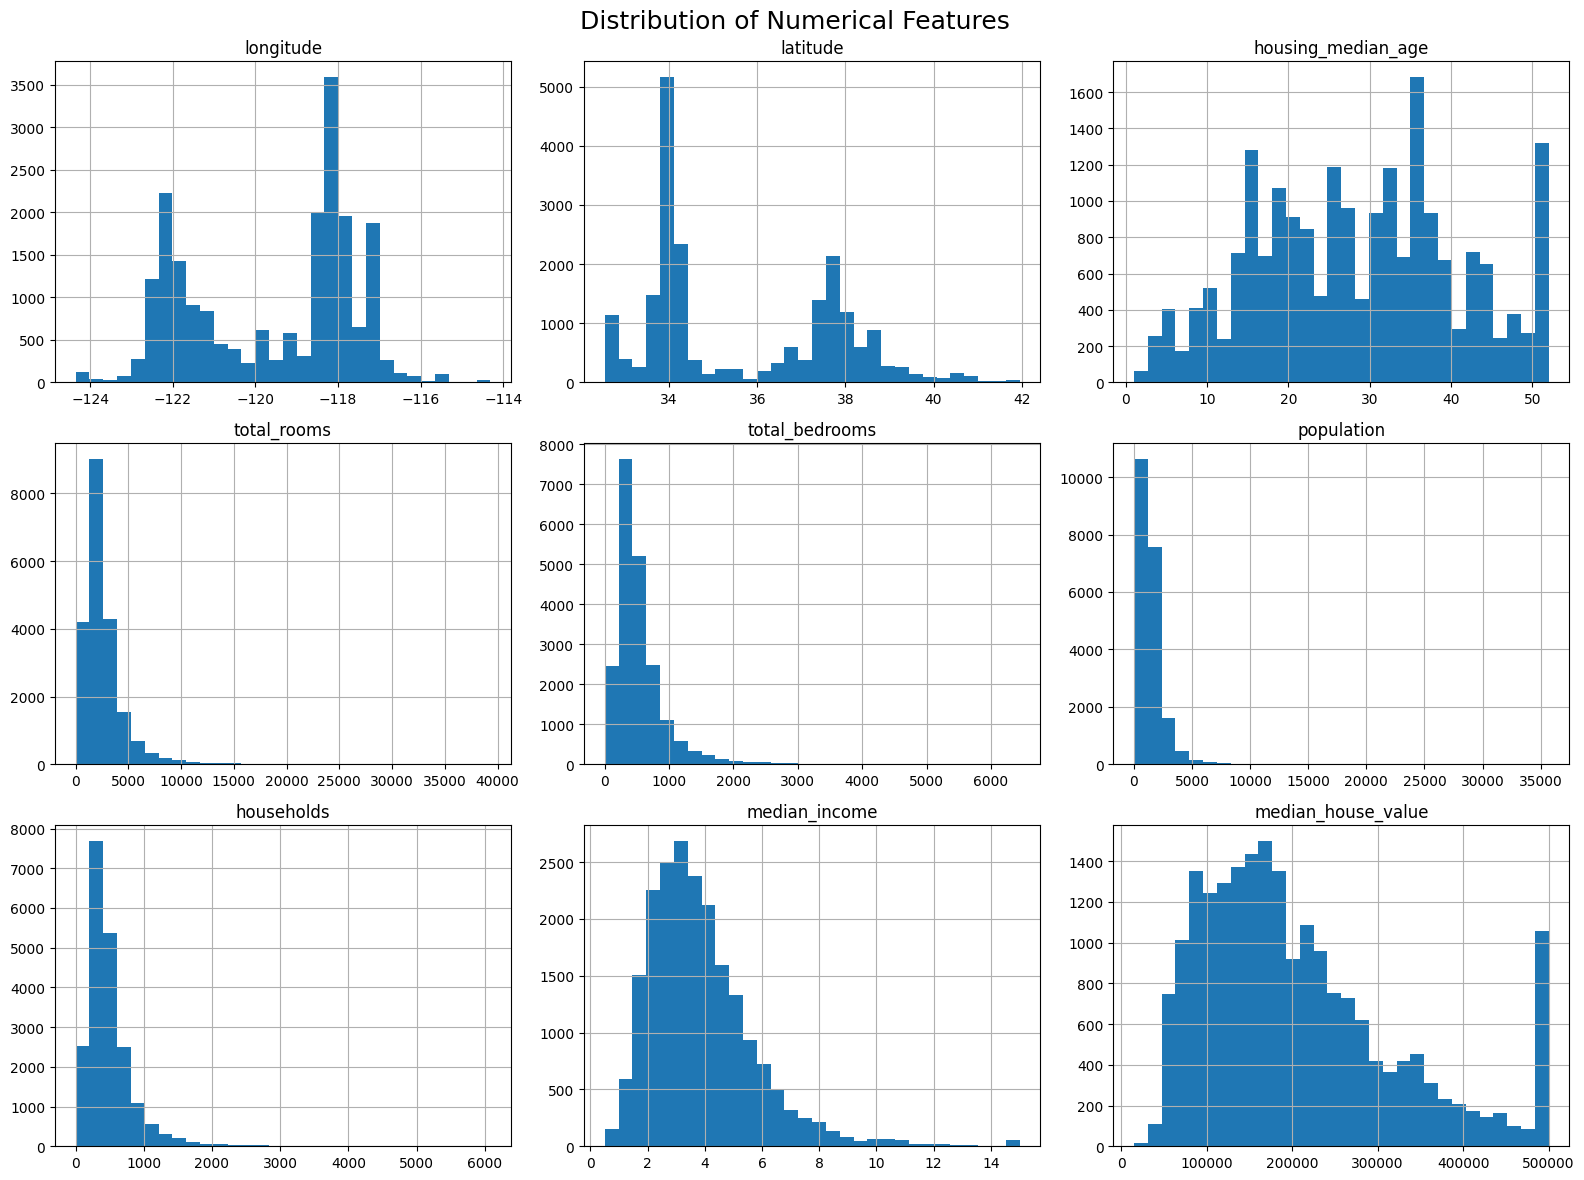

Feature Skewness
population            4.935858
total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
dtype: float64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear inside here
%matplotlib inline

# Improve plot appearance
plt.style.use("default")

# Display histograms for all numerical features
data.hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

# Calculate Skewness
print("Feature Skewness")
print(data.skew(numeric_only=True).sort_values(ascending=False))

##### Observation 
Based on the result, we observe that: 
- population is highly right-skewed.
- total_rooms is also right-skewed.
- median_income shows moderate right skew.

#### Boxplot
A boxplot is a statistical visualization that summarizes the distribution of a dataset using the median, quartiles, spread, and potential outliers.

```
        Outlier
           ●

      ─────────── Upper Whisker
           │
      ┌─────────┐
      │         │  ← Upper Quartile (Q3)
Median ─────────
      │         │
      └─────────┘  ← Lower Quartile (Q1)
           │
      ─────────── Lower Whisker

           ●
        Outlier
```

##### Different Indications
1. Many dots outside the whiskers
    - Many outliers exist
    - Data may contain unusual observations
    - Distribution may be skewed
    - Further investigation is recommended

2. Whiskers very long
    - Large variability
    - Wide spread of observations
    - High dispersion
    - Possible long-tailed distribution

3. Box is compressed (very small)
    - Middle 50% of observations are very close together
    - Low variability
    - Consistent values
    - Small Interquartile Range (IQR)

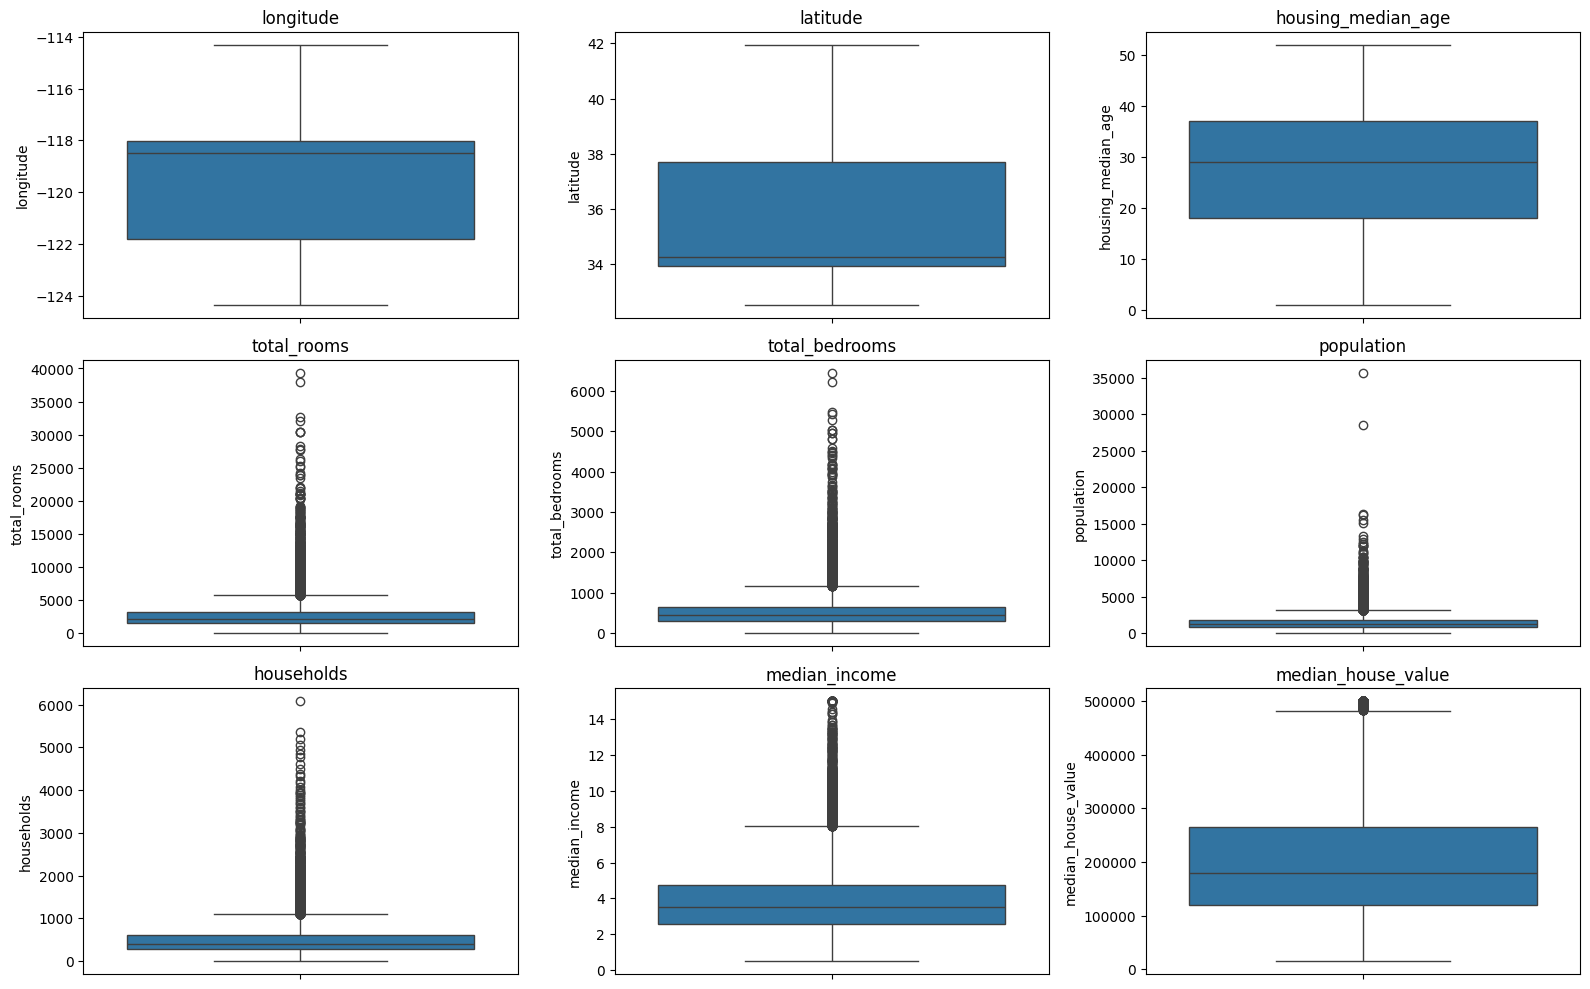

In [3]:
numerical_features = data.select_dtypes(include=['number']).columns
plt.figure(figsize=(16, 10))

for i, column in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=data[column])
    plt.title(column)

plt.tight_layout()
plt.show()

##### Observation 
The boxplots reveal that several numerical features contain potential outliers and exhibit varying degrees of skewness. Variables such as MedInc, Population, and AveOccup show noticeable extreme values, while others have more compact distributions. These outliers may represent valid observations rather than data errors, but they should be considered during model development because Linear Regression can be sensitive to extreme values.

### Bivariative Analysis 
Bivariative Analysis examines the relationship between two variables, usually one feature with another feature or with the target variable which helps to discover correlations, dependencies, and features that may be useful predictors for the machine learning model.

#### Correlation Matrix
Correlation measures the strength of a linear relationship between two numerical variables.

**For Example:**
- +1 (Perfect positive realtionship) 
- +0.8 (Strong positive realtionship )
- 0 (No linear relationship)
- -0.8 (Strong negative relationship)
- -1 (Perfect negative realtionship)

In [4]:
correlation_matrix = data.corr(numeric_only=True)
print("Correlation Matrix: ")
print(correlation_matrix)

Correlation Matrix: 
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      

#### Heatmap
A correlation heatmap visualizes the correlation coefficients between numerical features, helping identify the strength and direction of their relationships. Correlation values range from -1 to 1, where values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values near 0 indicate little or no linear relationship. During exploratory data analysis (EDA), a heatmap is commonly used to identify features that are strongly related to the target variable and to detect potential multicollinearity among predictors, supporting feature selection and model development.

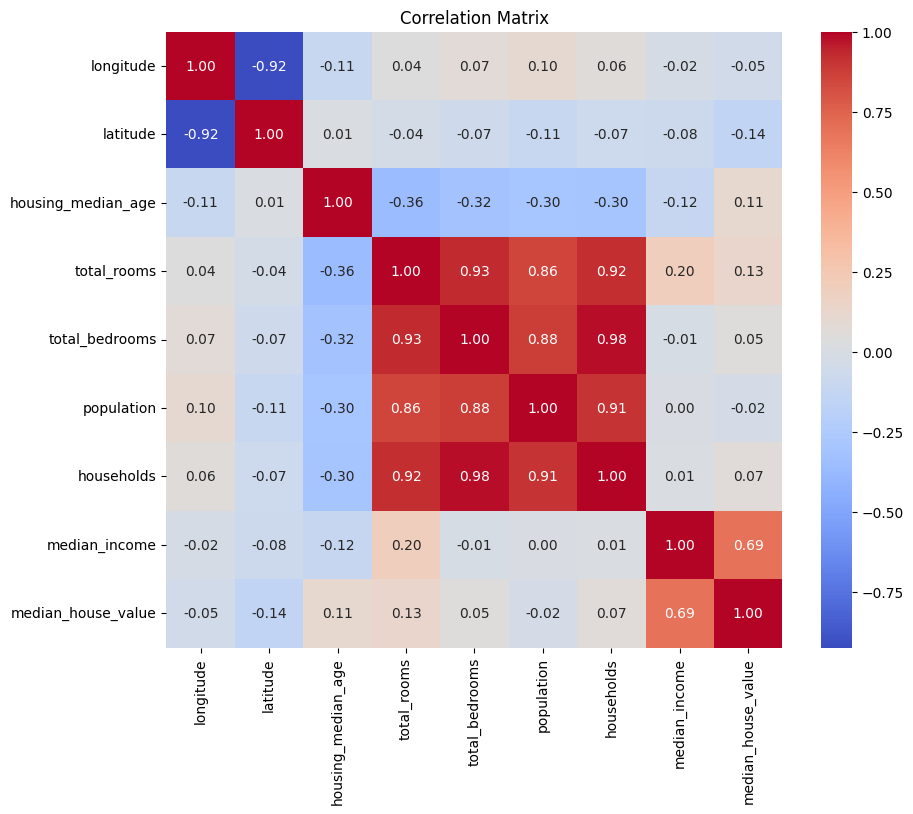

In [5]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix")
plt.show()

In [6]:
# Correlation with Target Variable
target_corr = correlation_matrix["median_house_value"] \
                .sort_values(ascending=False)

print(target_corr)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


##### Observation
- median_income has the strongest positive correlation with median_house_value.
- Geographic features (latitude and longitude) show weaker linear correlations but may still capture important spatial patterns.
- population has little linear correlation with the target.

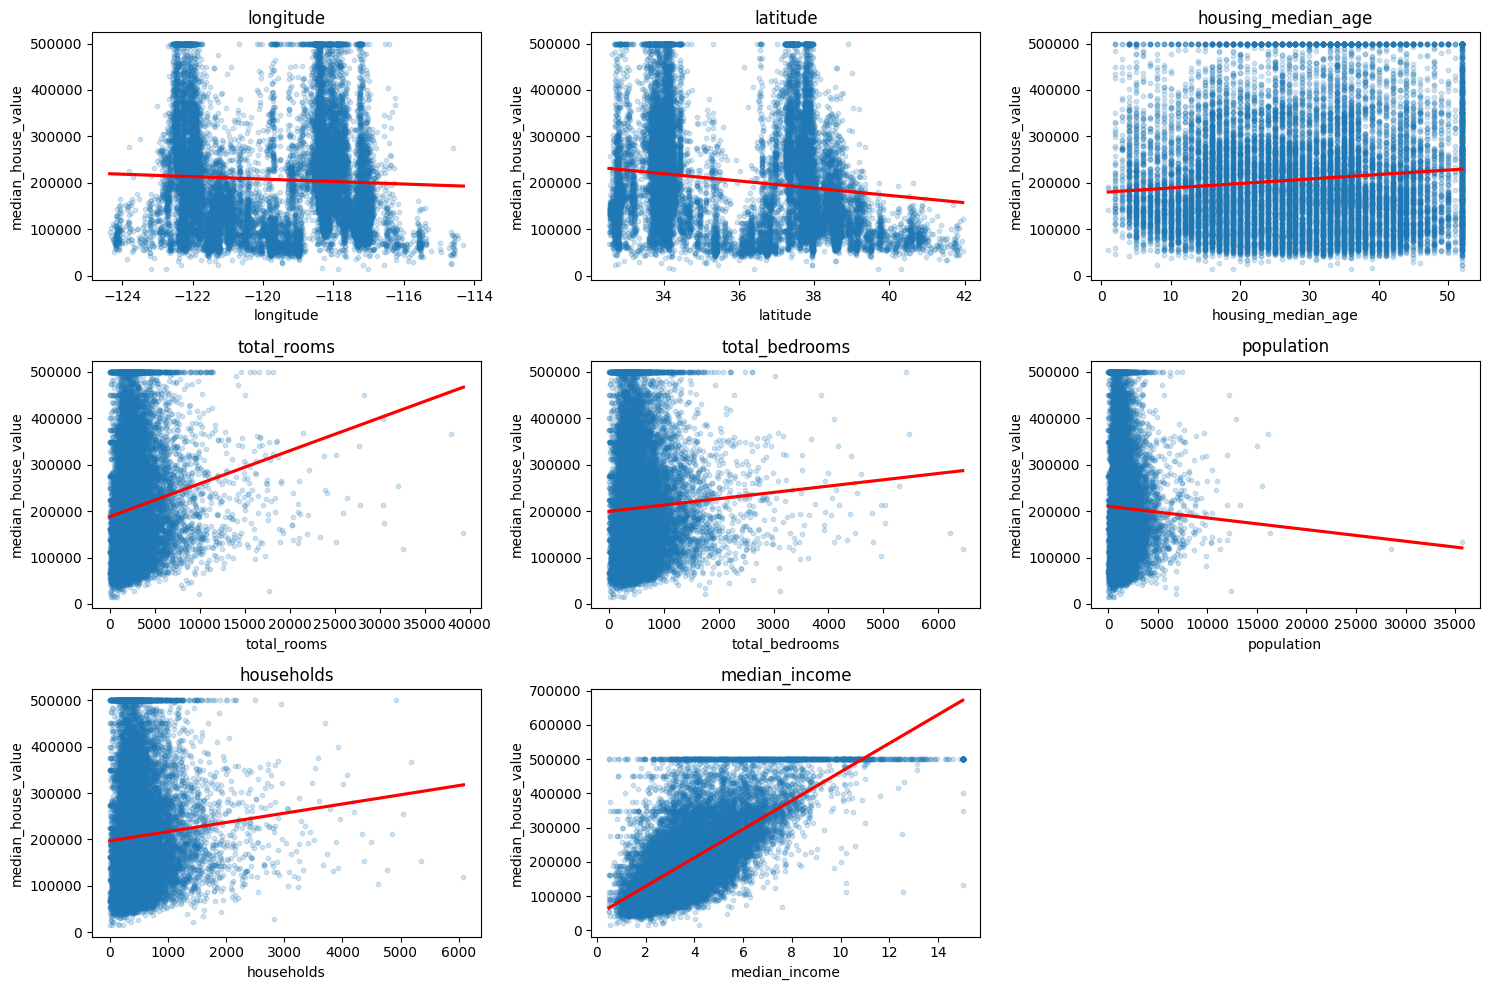

In [7]:
# Scatter Plot with Regression Line: Numerical Features vs Target
numerical_features = data.select_dtypes(include=["number"]).columns.drop("median_house_value")

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)

    sns.regplot(
        data=data,
        x=feature,
        y="median_house_value",
        scatter_kws={"alpha": 0.2, "s": 10},
        line_kws={"color": "red"},
        ci=None
    )

    plt.title(feature)

plt.tight_layout()
plt.show()

##### Observation
- House prices generally increase as median_income increases.
- The relationship between income and house price appears approximately linear, making it suitable for a baseline Linear Regression model.

### Multivariative Analysis 
Multivariative Analysis examines the relationships among three or more variables simultaneously to understand complex interactions and patterns which helps to identify feature interactions, multicollinearity, hidden structures, and combinations of variables that influence the target variable.

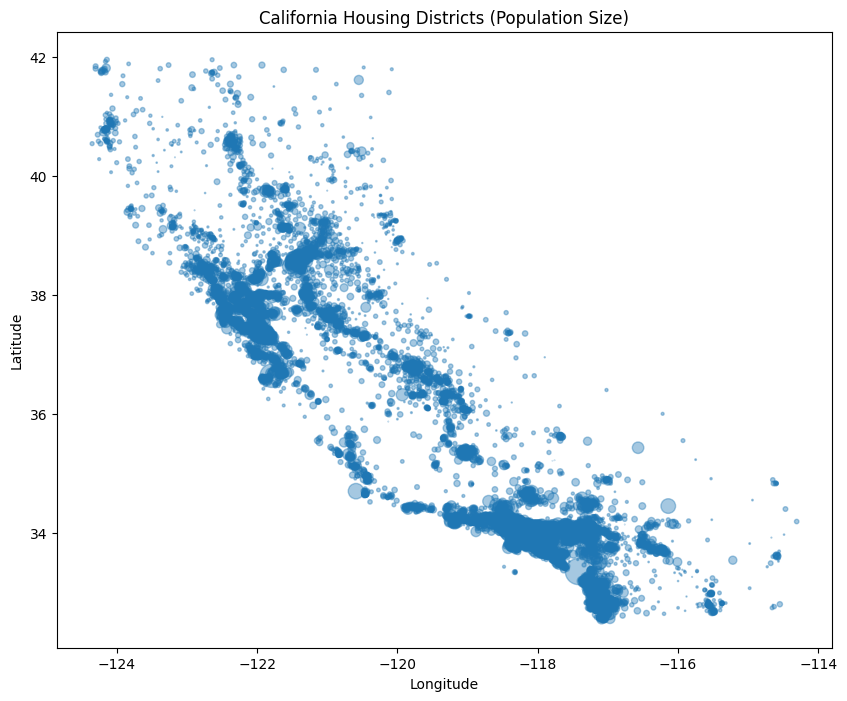

In [8]:
# Geographic Distribution with Population
plt.figure(figsize=(10, 8))

plt.scatter(
    data["longitude"],
    data["latitude"],
    alpha=0.4,
    s=data["population"] / 100,
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Districts (Population Size)")
plt.show()

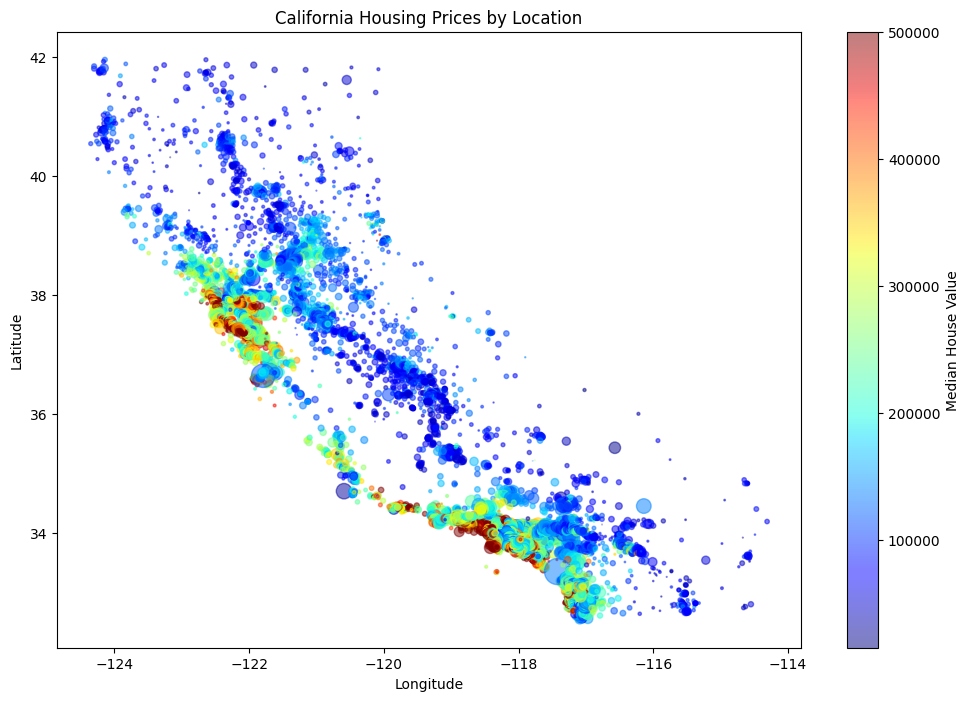

In [9]:
# Geographic Distribution with House Prices
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    data["longitude"],
    data["latitude"],
    c=data["median_house_value"],
    cmap="jet",
    alpha=0.5,
    s=data["population"] / 100
)

plt.colorbar(scatter, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices by Location")
plt.show()

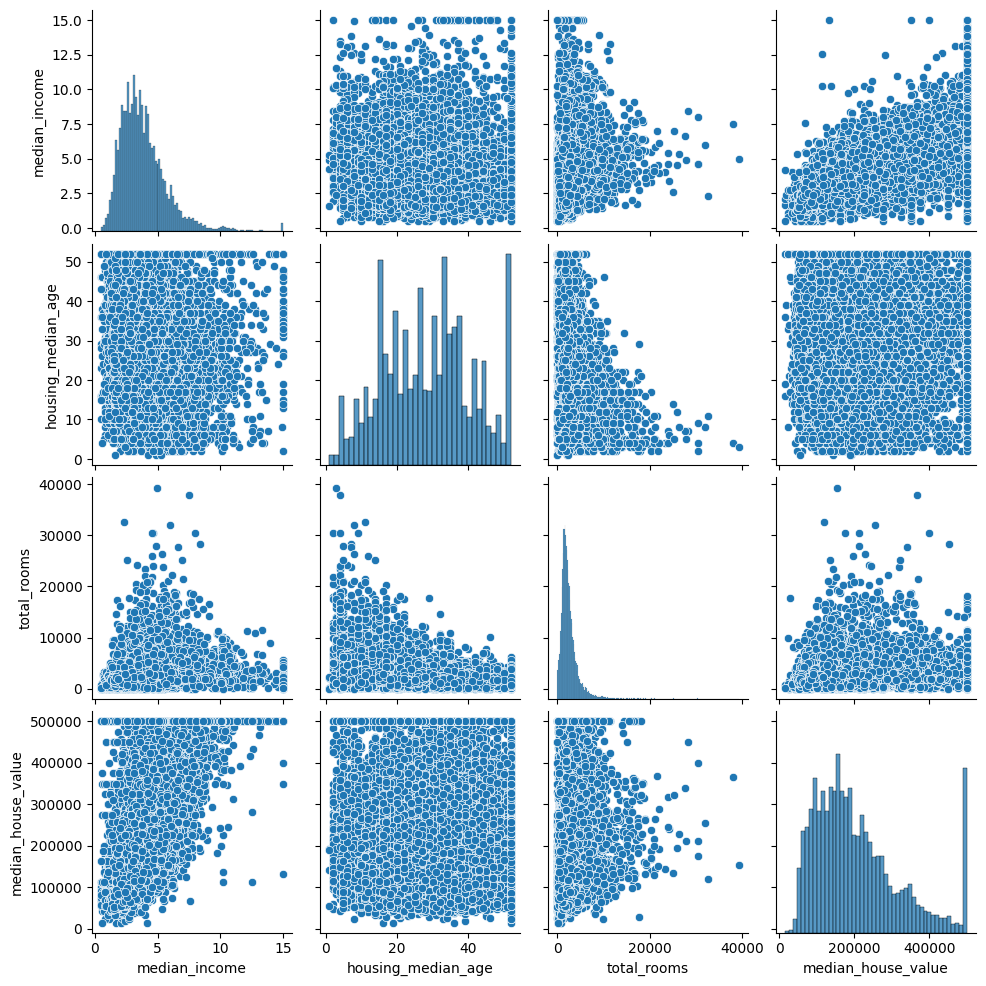

In [10]:
# Pairplot 
selected_features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "median_house_value"
]

sns.pairplot(data[selected_features])
plt.show()

A pairplot is an exploratory data analysis (EDA) visualization that displays the pairwise relationships between multiple numerical features in a dataset. It combines scatter plots for every pair of variables with histograms (or kernel density plots) along the diagonal, allowing both individual feature distributions and interactions between features to be examined in a single figure. This provides a quick and comprehensive overview of the dataset before model development.

#### Identifying Correlations
Pairplots help identify correlations by visualizing how two variables change together. If the scatter plot shows points forming an upward-sloping pattern, it indicates a positive correlation, meaning that as one feature increases, the other tends to increase as well. Conversely, a downward-sloping pattern suggests a negative correlation, where one variable decreases as the other increases. If the points are randomly scattered without any clear direction, it indicates little or no correlation. Visual inspection is particularly useful because it not only reveals the strength of a relationship but also its overall pattern.

#### Identifying Trends
Beyond simple correlations, pairplots allow the detection of trends within the data. A trend represents the overall direction or behavior of the relationship between two variables. For example, the relationship may be linear, where changes occur at a constant rate, or nonlinear, such as exponential, logarithmic, or curved patterns. Identifying these trends is valuable because some machine learning models assume linear relationships, while others can better capture more complex patterns.

#### Identifying Clusters
Pairplots can also reveal clusters, where observations naturally group together in the feature space. Instead of being evenly distributed, data points may form two or more distinct groups, suggesting that the dataset contains different categories or subpopulations. These clusters may indicate hidden structures within the data, potential class separations, or the presence of meaningful segments that can be further analyzed using clustering or classification algorithms.

#### Identifying Outliers
Outliers are observations that differ significantly from the majority of the data. In a pairplot, these appear as isolated points located far away from the main concentration of observations. Detecting outliers is important because they may represent data entry errors, measurement inaccuracies, or rare but legitimate events. Since outliers can disproportionately influence statistical analyses and machine learning models, identifying them early enables appropriate preprocessing decisions, such as investigation, removal, or transformation.

#### Understanding Feature Distributions
The diagonal plots in a pairplot display the distribution of each individual feature, typically using histograms or kernel density estimates. These plots help determine whether a variable follows a normal distribution, is skewed to the left or right, contains multiple peaks (multimodal), or includes extreme values. Understanding feature distributions is essential because it provides insight into data quality and guides preprocessing techniques such as normalization, standardization, logarithmic transformation, or outlier treatment before model training.

<br><br><br><br><br>

## Data Cleaning

Removing duplicate records is a data cleaning technique used to identify and eliminate repeated observations that do not contribute additional information to the dataset. Duplicate data can introduce bias, distort statistical analysis, and negatively affect machine learning model performance by causing certain patterns to be overrepresented. Additionally, duplicates may result in data leakage if identical samples appear in both training and testing datasets, leading to overly optimistic evaluation results. Therefore, duplicate records should be identified and handled before model training, while ensuring that legitimate repeated observations are not incorrectly removed.

In [11]:
# duplicates
duplicate_mask = data.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# data = data.drop_duplicates()
# print("Shape after dropping duplicates:", data.shape)

Number of duplicate rows: 0


<br><br><br><br><br>

## Data Preparation 

1. Train-Test Split	
    - Divides the dataset into separate training and testing sets. The training set is used to learn patterns, while the testing set is used to evaluate how well the trained model performs on unseen data.- Helps assess the model's ability to generalize to new data and prevents overly optimistic performance estimates.

2. Identify Numerical and Categorical Features	
    - Separates features based on their data types. Numerical features contain continuous or discrete numeric values, while categorical features represent groups or labels.	
    - Enables appropriate preprocessing techniques to be applied to each feature type, such as scaling numerical data and encoding categorical data.

In [12]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop("median_house_value", axis=1)
y = data["median_house_value"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42     # Ensure that everyone get the same split, cause without this, the rows are shuffled differently each time.
)

print("Training Set")
print(X_train.shape)

print("\n")

print("Testing Set")
print(X_test.shape)

Training Set
(16512, 9)


Testing Set
(4128, 9)


In [13]:
# Identify Numerical and Categorical Features

# Numerical features
numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()
print("Numerical Features:")
print(numerical_features)

print("\n")

# Categorical features
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
print("Categorical Features:")
print(categorical_features)

Numerical Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


Categorical Features:
['ocean_proximity']


In [14]:
# Identify Missing Values
print("Missing Values: ")
print(data.isnull().sum())

Missing Values: 
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


##### Observation 

1. Missing Value
    - total_bedrooms: 207 Missing Value (Count=20,433  Expected=20,640)
    - Data preprocessing is required before training a model. 

2. Categorical Feature
    - ocean_proximity (data type is object)
    - Linear Regression model cannot directly process text values, so this feature will need to be encoded into numerical form later.

<br><br><br><br><br>

## Data Preprocessing
Data preprocessing prepares the dataset for machine learning by handling missing values, transforming categorical variables into numerical form, and scaling numerical features. Since numerical and categorical features require different preprocessing techniques, they are processed separately before being combined into a single dataset for model training.

1. Missing Values (Numerical Features)

    Missing values in numerical features are replaced using Median Imputation, followed by Standard Scaling.

    - Median Imputation replaces missing values with the median, which is less affected by outliers and skewed data than the mean.
    - StandardScaler standardizes numerical features to have a mean of 0 and a standard deviation of 1, making features comparable and improving compatibility with scale-sensitive algorithms.

    Why Median Imputation?

    - Robust to outliers.
    - Suitable for skewed features such as population, total_rooms, and total_bedrooms.

    Why StandardScaler?

    - Makes feature values comparable.
    - Improves compatibility with algorithms such as KNN, SVM, and Neural Networks.
    - Creates a reusable preprocessing workflow.



2. Categorical Features

    Categorical features are preprocessed using Most Frequent Imputation and One-Hot Encoding.

    - Most Frequent Imputation replaces missing values with the most common category.
    - One-Hot Encoding converts categorical variables into binary numerical features so they can be used by machine learning models.

    Why handle_unknown="ignore"?

    Setting handle_unknown="ignore" prevents errors when unseen categories appear during prediction, making the model more robust.




**ColumnTransformer**

A ColumnTransformer applies different preprocessing techniques to different feature types in a single step.

- Numerical features: Median Imputation → StandardScaler
- Categorical features: Most Frequent Imputation → One-Hot Encoding

This ensures each feature is processed appropriately before model training.



**Pipeline**

A Pipeline combines all preprocessing steps into a single workflow, ensuring the same transformations are consistently applied during both training and prediction. This simplifies the workflow and helps prevent data leakage.

Why use names like "imputer" and "scaler"?

Each step in a scikit-learn Pipeline is assigned a name so it can be accessed later, for example:
```
pipeline.named_steps["scaler"]
```
This is useful for inspecting, debugging, or modifying specific preprocessing steps.

In [15]:
# Numerical Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical Preprocessing Pipeline:")
print(numerical_pipeline)
print("\n")



# Categorical Preprocessing Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical Preprocessing Pipeline:")
print(categorical_pipeline)
print("\n")



# Combine Numerical and Categorical Pipelines
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Combined Preprocessing Pipeline:")
print(preprocessor)
print("\n")

Numerical Preprocessing Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


Categorical Preprocessing Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


Combined Preprocessing Pipeline:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                              

<br><br><br><br><br>

## Build Baseline Model 

**What is a Baseline Model?**

A baseline model is the initial machine learning model built using a straightforward approach. Its primary purpose is to establish a reference point for model performance, allowing future models such as Ridge Regression, Lasso Regression, Random Forest, or Gradient Boosting to be compared against it.

**Why Linear Regression?**

Linear Regression is one of the simplest and most interpretable supervised learning algorithms for predicting continuous numerical values. It serves as an excellent starting point for understanding the relationship between the target variable and its features while providing a benchmark for evaluating more advanced regression models.


Before training the model, the dataset has been explored and preprocessed through data cleaning, feature selection, and train-test splitting. These steps help ensure that the data is suitable for model training and evaluation while reducing potential biases and data leakage.

The baseline Linear Regression model is trained using the training dataset to learn the relationship between the input features and the target variable. The trained model is then evaluated on the testing dataset to assess its predictive performance and generalization capability.

In [16]:
# Build Baseline Model
from sklearn.linear_model import LinearRegression

# Complete Machine Learning Pipeline
from sklearn.pipeline import Pipeline
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
print("Complete Machine Learning Pipeline:")
print(model_pipeline)
print("\n")

# Train the Pipeline
model_pipeline.fit(X_train, y_train)

Complete Machine Learning Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                       

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

<br><br><br><br><br>

## Model Evaluation (Baseline Model)
Model evaluation measures how well a regression model predicts unseen data by comparing predicted values with actual values using error-based and goodness-of-fit metrics.

### Performance Metrics
1. MAE (Mean Absolute Error)
    Average absolute prediction error.

    Example: MAE = 48,500
    → Predictions are off by about $48,500 on average
    
2. MSE (Mean Squared Error)
    Average squared error (penalizes large errors more heavily).

    Mainly used for mathematical optimization rather than interpretation.

3. RMSE (Root Mean Squared Error)
    Square root of MSE, same unit as target variable.

    Example: RMSE = 69,000
    → Typical prediction error is about $69,000

4. R² (Coefficient of Determination)
    Measures how much variance is explained by the model (0–1 scale).

    Example: R² = 0.64
    → Model explains 64% of the variation in house prices
    Not “64% accuracy”

5. Adjusted R²
    A refined version of R² that penalizes unnecessary features, useful for comparing models.

### Model Summary

A good regression model should have:
- Low MAE / RMSE → small prediction errors
- High R² / Adjusted R² → better explanation of data variance

Key Interpretation Rule
- Always interpret metrics in real-world meaning, not just numbers:
    - “RMSE of 69,000 means typical prediction error is around $69,000.”

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

# Train baseline metrics
train_baseline_pred = model_pipeline.predict(X_train)
train_baseline_mse = mean_squared_error(y_train, train_baseline_pred)
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("TRAIN BASELINE METRICS: ")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"R2  : {train_baseline_r2:.4f}")
print("\n")

# Test baseline metrics
test_baseline_pred = model_pipeline.predict(X_test)
test_baseline_mse = mean_squared_error(y_test, test_baseline_pred)
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("TEST BASELINE METRICS: ")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.4f}")

TRAIN BASELINE METRICS: 
RMSE: 68433.937
MAE : 49594.842
R2  : 0.6497


TEST BASELINE METRICS: 
RMSE: 70059.193
MAE : 50670.489
R2  : 0.6254


<br><br><br><br><br>

## Model Interpretation

This section examines how the trained Linear Regression model makes predictions by analyzing the learned coefficients and intercept. The coefficients indicate the direction and magnitude of each feature's influence on the target variable, while the intercept represents the model's baseline prediction when all input features are zero. Interpreting these parameters helps explain the relationships learned by the model and provides valuable business insights beyond predictive performance.

### Feature Importance
The feature coefficients are analyzed to identify which variables have the greatest influence on house price predictions. Features with larger absolute coefficient values contribute more significantly to the model, while the sign of the coefficient indicates whether the relationship with the target variable is positive or negative.

### Business Insight
Model interpretation provides insights into the factors that influence house prices, enabling stakeholders to understand not only the model's predictions but also the relative importance of different variables. These insights can support data-driven decision-making, feature selection, and future model improvements.


In [18]:
# Feature Importance (Linear Regression Coefficients)
# Get trained Linear Regression model
regressor = model_pipeline.named_steps["model"]

# Get transformed feature names
feature_names = model_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": regressor.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(importance)

                            Feature    Coefficient
10      cat__ocean_proximity_ISLAND  117198.489753
7                num__median_income   75167.774766
9       cat__ocean_proximity_INLAND  -58713.239023
1                     num__latitude  -54415.696144
0                    num__longitude  -53826.648016
5                   num__population  -43403.432427
4               num__total_bedrooms   43068.181842
11    cat__ocean_proximity_NEAR BAY  -24063.225079
8    cat__ocean_proximity_<1H OCEAN  -18926.582862
6                   num__households   18382.196324
12  cat__ocean_proximity_NEAR OCEAN  -15495.442789
2           num__housing_median_age   13889.866189
3                  num__total_rooms  -13094.251162


<Figure size 1000x800 with 0 Axes>

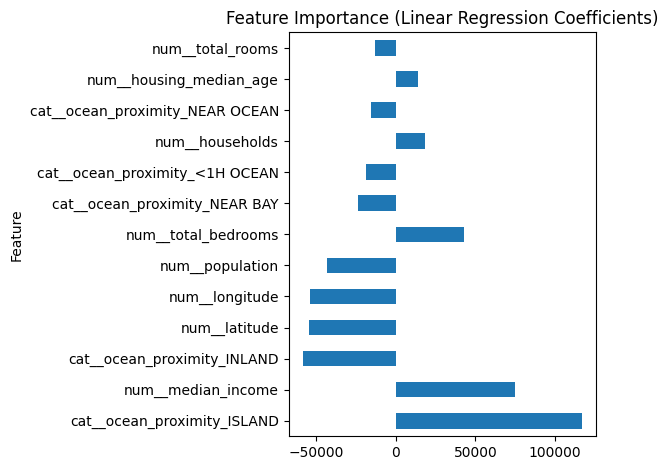

In [19]:
## Visualize Feature Importance
plt.figure(figsize=(10,8))

importance.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    legend=False
)

plt.title("Feature Importance (Linear Regression Coefficients)")
plt.tight_layout()
plt.show()

In [20]:
print("Model Equation: ")

print(f"y = {regressor.intercept_:.4f}")

for feature, coef in zip(feature_names, regressor.coef_):
    print(f"{coef:.4f} * {feature}")

Model Equation: 
y = 238826.3594
-53826.6480 * num__longitude
-54415.6961 * num__latitude
13889.8662 * num__housing_median_age
-13094.2512 * num__total_rooms
43068.1818 * num__total_bedrooms
-43403.4324 * num__population
18382.1963 * num__households
75167.7748 * num__median_income
-18926.5829 * cat__ocean_proximity_<1H OCEAN
-58713.2390 * cat__ocean_proximity_INLAND
117198.4898 * cat__ocean_proximity_ISLAND
-24063.2251 * cat__ocean_proximity_NEAR BAY
-15495.4428 * cat__ocean_proximity_NEAR OCEAN


##### Observation 
The coefficient analysis shows that different features contribute to the predicted house prices with varying levels of influence. Features with larger absolute coefficient values have a greater impact on the model's predictions, while positive coefficients indicate a direct relationship with house prices and negative coefficients indicate an inverse relationship. The results suggest that the model successfully learns meaningful relationships between the input features and the target variable.

<br><br><br><br><br>

## Model Seclection
Model Selection and Optimization are important stages in the machine learning workflow that focus on identifying the most suitable model and improving its predictive performance. Model selection involves comparing different algorithms to determine which model best captures the underlying patterns in the dataset while maintaining good generalization on unseen data. 

In [21]:
# models to try
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),  # RANDOM_STATE (can modified if wanted to change the random state)
    "Lasso": Lasso(random_state=42, max_iter=10000),    # the maximum number of iterations allowed for model convergence.
    "RandomForest": RandomForestRegressor(),
    "HistGB": HistGradientBoostingRegressor()
}

A collection of machine learning regression models that will be evaluated and compared to determine which algorithm performs best on the given dataset. 

- Linear Regression establishes a simple baseline model by learning linear relationships between features and the target variable
- Ridge and Lasso introduce regularization techniques to reduce model complexity and prevent overfitting
- Random Forest improves prediction performance by combining multiple decision trees
- HistGradientBoostingRegressor builds trees sequentially to correct previous prediction errors.

In [22]:
from sklearn.model_selection import KFold
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=42)

K-Fold Cross-Validation divides the training data into multiple subsets (called folds) and trains the model multiple times using different combinations of training and validation data. 

- `n_splits=5` means the dataset is divided into five folds. The model is trained five times, where each fold is used once as the validation set while the remaining folds are used for training. 
- `shuffle=True` parameter randomly shuffles the dataset before splitting to ensure that the samples are distributed more evenly.
- `random_state=42` parameter ensures that the same data partitioning is generated every time, allowing the experiment to be reproduced consistently

In [23]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

- RMSE measures the average magnitude of prediction errors while giving higher penalties to larger errors, making it useful for identifying models that produce significant prediction mistakes.
- MAE measures the average absolute difference between predicted and actual values, providing an easier interpretation of prediction error. 
- The R² score represents how well the model explains the variation in the target variable, where a value closer to 1 indicates better predictive performance. 
- The neg_ prefix used for RMSE and MAE is required by Scikit-learn because its cross-validation framework assumes that higher scores represent better performance. Therefore, these negative values are converted back to positive values later when calculating the average evaluation results.

In [24]:
from sklearn.model_selection import cross_validate

rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()        
    })


# sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("Cross Validation Model Comparison: ")
print(cv_results)

Cross Validation Model Comparison: 
              model       cv_rmse        cv_mae     cv_r2
4            HistGB  48318.355317  32427.490758  0.825300
3      RandomForest  49432.157220  32296.416371  0.817162
1             Ridge  68595.617399  49664.330927  0.647760
2             Lasso  68603.233277  49667.262611  0.647685
0  LinearRegression  68604.162955  49667.159067  0.647676


Cross-validation is performed for each candidate model and records their performance results. For each model, a Scikit-learn Pipeline is created that combines the preprocessing steps and the machine learning algorithm into a single workflow. The pipeline ensures that preprocessing operations, such as missing value imputation, encoding, and scaling, are correctly applied during each cross-validation fold without causing data leakage.

`cross_validate()` function trains and evaluates the model using the defined K-Fold strategy and calculates the selected evaluation metrics.

Average RMSE, MAE, and R² scores across all folds are calculated and stored inside the rows list. This process allows multiple models to be compared fairly using the same dataset preparation and evaluation procedure.

In [25]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on Cross Validation RMSE:")
print("Model :", best_model_name)
print("Cross Validation RMSE:", best_rmse)

Best model based on Cross Validation RMSE:
Model : HistGB
Cross Validation RMSE: 48318.355317423244


The best-performing model is identified based on the cross-validation RMSE score. The `sort_values("cv_rmse")` function arranges all models from the lowest to highest RMSE, and .iloc[0] selects the first row, which represents the model with the smallest prediction error.

##### Observation 
The HistGradientBoostingRegressor (HistGB) achieved the best cross-validation performance among the evaluated models, obtaining the lowest CV RMSE value of 48,226.63. This indicates that HistGB provided the most accurate predictions on unseen data during model validation and was selected as the final model for further evaluation and deployment.

<br><br><br><br><br>

## Hyperparameter Tuning (Optimization)
After selecting an appropriate model, optimization is performed by tuning model parameters and hyperparameters to improve accuracy, reduce errors, and prevent issues such as overfitting or underfitting. Techniques such as Grid Search and Random Search are commonly used to find the optimal model configuration. These processes help ensure that the final model is reliable, efficient, and capable of producing accurate predictions.

In [26]:
# Create HistGradientBoostingRegressor Pipepline
hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", HistGradientBoostingRegressor(random_state=42))
    ]
)

In [27]:
# hyperparameters combination
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

The hyperparameter search space used by GridSearchCV to optimize the HistGradientBoostingRegressor model. Each parameter represents a different aspect of the model's learning behavior, and multiple values are provided so that GridSearchCV can evaluate different combinations and identify the best-performing configuration.

- `model__learning_rate` parameter controls the contribution of each decision tree during the boosting process, where smaller learning rates generally provide more stable learning but require more iterations. 
- `model__max_depth` parameter controls the maximum depth of each decision tree, affecting the model's complexity and ability to capture complex relationships within the data.
- `model__max_leaf_nodes` parameter limits the number of leaf nodes in each tree, helping control model complexity and prevent overfitting.
- `model__min_samples_leaf` parameter specifies the minimum number of samples required in each leaf node, where larger values create simpler trees with better generalization. 
- `model__l2_regularization` parameter introduces L2 regularization to reduce overfitting by penalizing overly complex models. 
- prefix "model__" is required because the HistGradientBoostingRegressor is located inside the pipeline under the step name "model", allowing GridSearchCV to correctly access and tune these parameters.

In [28]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

The code initializes a GridSearchCV object to perform hyperparameter tuning on the HistGradientBoosting pipeline. GridSearchCV is a systematic optimization method that evaluates different combinations of hyperparameter values to identify the configuration that provides the best model performance. 

- `estimator` parameter specifies the machine learning model to be optimized, which is the hgb_pipe pipeline containing both preprocessing and the HistGradientBoostingRegressor model.
- `param_grid` parameter defines the range of hyperparameter combinations that will be tested during the search process.
- `cv` parameter specifies the cross-validation strategy used to evaluate each combination, ensuring that the selected parameters generalize well to unseen data.
- evaluation metric is defined using neg_root_mean_squared_error, which represents the negative RMSE value because Scikit-learn internally maximizes scoring metrics, while RMSE itself is a metric where lower values indicate better performance. 
- `n_jobs=-1` setting allows the process to utilize all available CPU cores to speed up computation
- `verbose=1` provides progress information during the grid search execution.

In [29]:
# perform grid search
grid.fit(X_train, y_train)
print("Tuned HistGB (CV) Result: ")
print("Best CV RMSE:", -grid.best_score_)
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Tuned HistGB (CV) Result: 
Best CV RMSE: 47327.96653299736
Best params: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


- `grid.fit(X_train, y_train)` command trains multiple versions of the HistGradientBoosting model using different hyperparameter combinations defined in the parameter grid. Each configuration is evaluated using cross-validation, and the model with the best validation performance is selected automatically. 
- `grid.best_score_` returns the highest cross-validation score achieved during optimization after completing the search. Since the scoring method uses negative RMSE, the negative sign is applied (-grid.best_score_) to convert the value back into the normal RMSE format, where a smaller value indicates better prediction performance.
- `grid.best_params_` attribute displays the optimal hyperparameter combination that achieved the best cross-validation result. These optimized parameters can then be used to create the final HistGradientBoosting model with improved predictive performance compared with the default configuration.

<br><br><br><br><br>

## Retraining with best parameters
The best hyperparameters identified through GridSearchCV were used to retrain the HistGradientBoostingRegressor model using the complete training dataset. This step ensures that the final model is optimized with the selected parameters before evaluating its performance on unseen test data.

In [30]:
hgb_best = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", HistGradientBoostingRegressor(
            l2_regularization=0.1,
            learning_rate=0.1,
            max_depth=None,
            max_leaf_nodes=63,
            min_samples_leaf=20
        ))
    ]
)

# train best model on entire training data (can also be done with refit=True in grid search)
hgb_best.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

The final HistGradientBoostingRegressor model was reconstructed using the optimal hyperparameters identified from GridSearchCV. The optimized pipeline combines preprocessing and model training, then retrains the model on the complete training dataset to maximize learning from available data before final performance evaluation.

<br><br><br><br><br>

## Final Evaluation 
The selected and optimized machine learning model is assessed using an independent test dataset that was not involved during model training or tuning. This step provides an unbiased measurement of the model's ability to generalize to unseen data. Evaluation metrics such as RMSE, MAE, and R² score are commonly used for regression problems to measure prediction error and overall model performance. The results from the final evaluation indicate whether the developed model is reliable and suitable for making predictions in real-world applications.

In [31]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("Final Model (Tuned HGB) Train Performance: ")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2  : {train_final_r2:.3f}")

Final Model (Tuned HGB) Train Performance: 
RMSE: 35881.437
MAE : 24465.037
R2  : 0.904


The performance of the final optimized HistGradientBoostingRegressor model (hgb_best) is evaluated on the training dataset. 

The predict() function is used to generate predictions (train_final_pred) based on the training features (X_train). These predicted values are then compared with the actual target values (y_train) using three regression evaluation metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R² score.

In [32]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("Final Model (Tuned HGB) Test Performance: ")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2  : {test_final_r2:.3f}")

Final Model (Tuned HGB) Test Performance: 
RMSE: 46378.260
MAE : 30660.502
R2  : 0.836


The final trained model is evaluated using the independent test dataset, which contains unseen data that was not used during model training or hyperparameter optimization

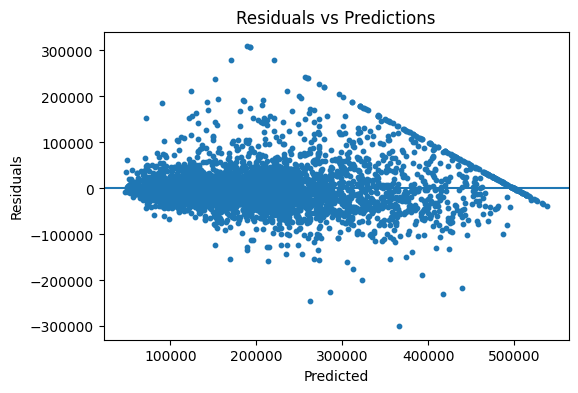

In [33]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

`residuals = y_test - test_final_pred` calculates the residuals, which represent the difference between the actual target values and the model's predicted values.

A positive residual means that the model underestimated the prediction, while a negative residual means that the model overestimated the prediction. Residual analysis is important because it provides additional insight into model behavior beyond numerical evaluation metrics.

This visualization creates a scatter plot showing the relationship between predicted values and residual errors. The predicted values are displayed on the x-axis, while residual values are displayed on the y-axis. The horizontal line at zero represents perfect prediction, where the actual value equals the predicted value. Ideally, residual points should be randomly distributed around this line with no obvious patterns. A random distribution suggests that the model has successfully captured the underlying patterns in the data. However, visible patterns, increasing spread, or curved structures may indicate problems such as non-linearity, missing important features, or heteroscedasticity (unequal error variance).

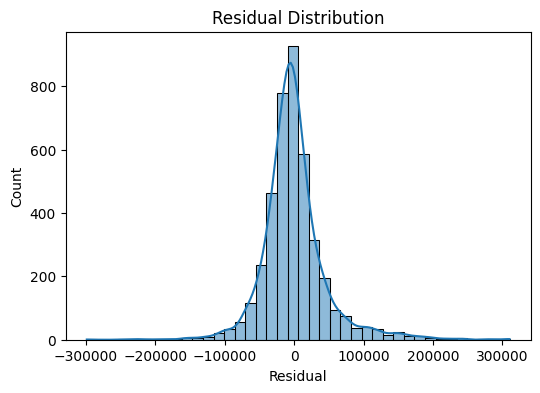

In [34]:
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

The distribution of residual errors is visualize using a histogram with a Kernel Density Estimate (KDE) curve. The purpose of this plot is to examine whether the residuals follow an approximately normal distribution and whether the prediction errors are centered around zero. A well-performing regression model typically produces residuals that are symmetrically distributed around zero, indicating that the model does not consistently overestimate or underestimate predictions. Significant skewness or extreme values may suggest the presence of outliers, systematic prediction errors, or areas where the model could be improved.

<br><br><br><br><br>

## Buiding a Predictive System

In [35]:
def predict_house_price(
    model,
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:
    """
    Predict median_house_value for one new house.
    total_bedrooms can be np.nan (pipeline will impute).
    """
    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity
    }])

    return float(model.predict(new_row)[0])

In [36]:
# Example inference
example_pred = predict_house_price(
    model=hgb_best,
    longitude=-122.230,
    latitude=37.880,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
 )

print("\nExample prediction:", round(example_pred, 2))


Example prediction: 443495.12


<br><br><br><br><br>

## Model Deployment 
Model deployment is the final stage of the machine learning workflow, where the trained model is saved, reused, and applied to make predictions on new data. This ensures that the model is not limited to the current session and can be integrated into real-world applications.

### Model Persistence & Saving the Trained Model
Model persistence refers to saving the trained machine learning model to disk so it can be reused later without retraining. This is typically done using libraries such as joblib or pickle.

After training, the model is stored as a file (e.g., .pkl or .joblib). This allows the model, along with its learned parameters and preprocessing pipeline, to be preserved for future use.

### Loading the Model & Making Predictions
The saved model can be reloaded into memory whenever needed. This ensures that the exact same trained model is used for prediction, maintaining consistency across different sessions.

Once loaded, the model can be used to make predictions on new, unseen data. The input data must go through the same preprocessing steps as the training data to ensure accurate results.

In [37]:
# Save the model 
import joblib

joblib.dump(
    hgb_best,
    "california_FinalHistGradientBoostingRegressor.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [38]:
# Load the model 
loaded_model = joblib.load(
    "california_FinalHistGradientBoostingRegressor.pkl"
)
print("Model loaded successfully!")



# Predict 
prediction = loaded_model.predict(X_test)
print(prediction[:5])

Model loaded successfully!
[ 57405.34253065  73369.61017197 473681.51180232 261496.00632145
 275166.1997486 ]
